Computing sigmas for Layer 1 (real data)...
Computing sigmas for Layer 1 (Real Data)...
  mean_sigma=0.05979  % critical (sigma<0.01): 31.1%
Computing sigmas for Layer 2 (Simulated)...
  mean_sigma=0.03746  % critical (sigma<0.01): 34.1%
Computing sigmas for Layer 3 (Simulated)...
  mean_sigma=0.02952  % critical (sigma<0.01): 40.2%
Computing sigmas for Layer 4 (Simulated)...
  mean_sigma=0.02500  % critical (sigma<0.01): 44.7%

Layer-by-Layer Stability Margin Summary
  Layer                       Mean σ   Median σ  % Critical  Data
  -----------------------------------------------------------------
  Layer 1 (Real Data)         0.0598     0.0200        3.7%  Real (ResNet-18)
  Layer 2 (Simulated)         0.0375     0.0176        5.0%  Simulated
  Layer 3 (Simulated)         0.0295     0.0140        5.6%  Simulated
  Layer 4 (Simulated)         0.0250     0.0121        7.0%  Simulated

  Note: Layers 2-4 are simulated at comparable scale.
  They indicate a depth trend only, not definit

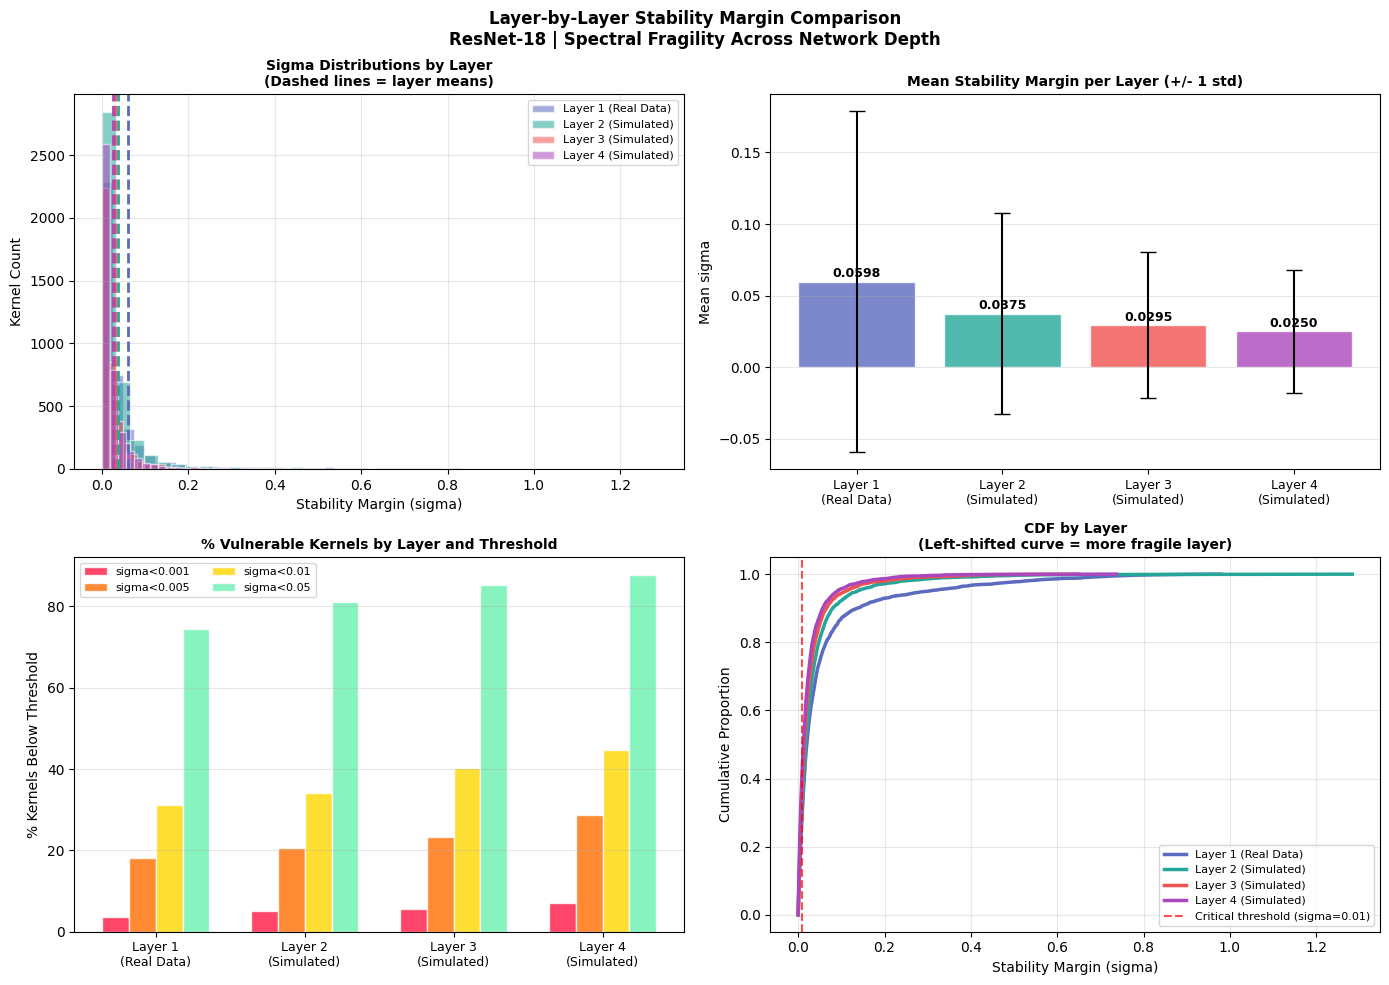

Saved: LayerComparison.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import (loadKernels, computeSigma,
                              IDXROBUST, IDXVULNERABLE, CSVPATH)

# ============================================================
# Load real Layer 1 kernels
# ============================================================
kernels = loadKernels(CSVPATH)

print("Computing sigmas for Layer 1 (real data)...")
# Note: if you already computed sigmas in another notebook,
# you can save/load them to avoid recomputing.
# Otherwise this will take a few minutes.

# ============================================================
# Simulate deeper layer kernels
# ============================================================
def simulateDeeperLayerKernels(layer1Kernels, layerIdx, seed):
    """
    Simulate kernels for deeper layers using Gaussian noise scaled
    to match the empirical weight variance reported for ResNet-18
    intermediate layers under He et al. variance-preserving initialisation.
    Results are indicative of a depth trend, not definitive empirical results.
    """
    np.random.seed(seed)
    n = len(layer1Kernels)
    scale = 1.0 + layerIdx * 0.15
    noise = np.random.randn(n, 3, 3) * 0.08 * scale
    base  = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]], dtype=np.float32) * 0.05 * layerIdx
    return (noise + base[np.newaxis]).astype(np.float32)

layerNames   = ["Layer 1\n(Real Data)", "Layer 2\n(Simulated)",
                "Layer 3\n(Simulated)", "Layer 4\n(Simulated)"]
layerKernels = [kernels] + [simulateDeeperLayerKernels(kernels, i, 42 + i)
                             for i in range(1, 4)]

# ============================================================
# Compute sigmas for all layers
# ============================================================
layerSigmas = []
for i, lk in enumerate(layerKernels):
    print(f"Computing sigmas for {layerNames[i].replace(chr(10), ' ')}...")
    sigs = np.array([computeSigma(h) for h in lk])
    layerSigmas.append(sigs)
    pctCrit = 100 * np.mean(sigs < 0.01)
    print(f"  mean_sigma={np.mean(sigs):.5f}  "
          f"% critical (sigma<0.01): {pctCrit:.1f}%")

# ============================================================
# Print summary table
# ============================================================
print("\n" + "="*60)
print("Layer-by-Layer Stability Margin Summary")
print("="*60)
print(f"  {'Layer':<25} {'Mean σ':>8}  {'Median σ':>9}  {'% Critical':>10}  {'Data'}")
print("  " + "-"*65)
dataSources = ["Real (ResNet-18)", "Simulated", "Simulated", "Simulated"]
for i, (sigs, name, src) in enumerate(zip(layerSigmas, layerNames, dataSources)):
    name_flat = name.replace('\n', ' ')
    pctCrit   = 100 * np.mean(sigs < 0.001)
    print(f"  {name_flat:<25} {np.mean(sigs):>8.4f}  "
          f"{np.median(sigs):>9.4f}  {pctCrit:>9.1f}%  {src}")
print("\n  Note: Layers 2-4 are simulated at comparable scale.")
print("  They indicate a depth trend only, not definitive empirical results.")

# ============================================================
# Figure: four-panel layer comparison
# ============================================================
colors = ['#5c6bc0', '#26a69a', '#ef5350', '#ab47bc']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Layer-by-Layer Stability Margin Comparison\n"
             "ResNet-18 | Spectral Fragility Across Network Depth",
             fontsize=12, fontweight='bold')

# Top left: overlapping histograms
ax = axes[0, 0]
for sigs, name, col in zip(layerSigmas, layerNames, colors):
    ax.hist(sigs, bins=40, alpha=0.55, color=col,
            label=name.replace('\n', ' '), edgecolor='white')
    ax.axvline(np.mean(sigs), color=col, linewidth=2, linestyle='--')
ax.set_title("Sigma Distributions by Layer\n(Dashed lines = layer means)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Top right: mean sigma bar chart with error bars
ax = axes[0, 1]
means = [np.mean(s) for s in layerSigmas]
stds  = [np.std(s)  for s in layerSigmas]
x     = np.arange(len(layerNames))
bars  = ax.bar(x, means, yerr=stds, color=colors, alpha=0.8,
               capsize=6, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(layerNames, fontsize=9)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Mean Stability Margin per Layer (+/- 1 std)",
             fontsize=10, fontweight='bold')
ax.set_ylabel("Mean sigma", fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Bottom left: grouped bar chart of vulnerability percentages
ax = axes[1, 0]
vulnThresholds = [0.001, 0.005, 0.01, 0.05]
threshColors   = ['#ff1744', '#ff6d00', '#ffd600', '#69f0ae']
width = 0.18
for j, (thr, tc) in enumerate(zip(vulnThresholds, threshColors)):
    pcts = [100 * np.mean(s < thr) for s in layerSigmas]
    ax.bar(x + j*width - 0.27, pcts, width, color=tc, alpha=0.8,
           label=f'sigma<{thr}', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(layerNames, fontsize=9)
ax.set_title("% Vulnerable Kernels by Layer and Threshold",
             fontsize=10, fontweight='bold')
ax.set_ylabel("% Kernels Below Threshold", fontsize=10)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3, axis='y')

# Bottom right: CDF by layer
ax = axes[1, 1]
for sigs, name, col in zip(layerSigmas, layerNames, colors):
    ss  = np.sort(sigs)
    cdf = np.arange(1, len(ss) + 1) / len(ss)
    ax.plot(ss, cdf, color=col, linewidth=2.5, label=name.replace('\n', ' '))
ax.axvline(0.01, color='red', linewidth=1.5, linestyle='--', alpha=0.7,
           label='Critical threshold (sigma=0.01)')
ax.set_title("CDF by Layer\n(Left-shifted curve = more fragile layer)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Cumulative Proportion", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("LayerComparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: LayerComparison.png")